In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
df = pd.read_csv("../Output/cleaned_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount,hour,day,month,is_weekend,age_group,revenue_category
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0,15,Saturday,August,True,35-44,Non-Purchaser
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0,10,Monday,April,False,25-34,Non-Purchaser
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0,21,Wednesday,August,False,35-44,Non-Purchaser
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0,3,Wednesday,March,False,25-34,Non-Purchaser
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0,13,Sunday,December,True,25-34,Non-Purchaser


In [2]:
group_counts = df["group"].value_counts()

group_counts

group
treatment    147552
control      146926
Name: count, dtype: int64

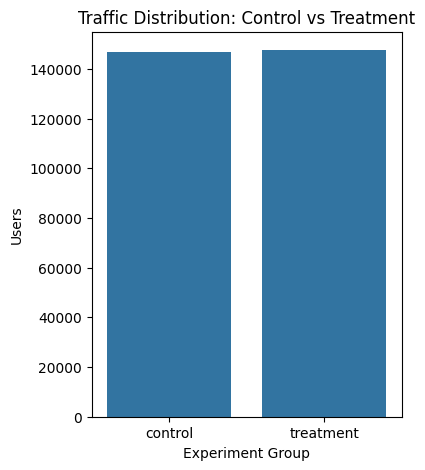

In [5]:
plt.figure(figsize=(4, 5))

sns.countplot(
    data=df,
    x="group"
)

plt.title("Traffic Distribution: Control vs Treatment")
plt.xlabel("Experiment Group")
plt.ylabel("Users")

plt.show()

In [6]:
group_distribution = (
    df["group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

group_distribution

group
treatment    50.11
control      49.89
Name: proportion, dtype: float64

In [7]:
experiment_summary = (
    df.groupby("group")
      .agg(
          users=("user_id", "nunique"),
          avg_session_duration=("session_duration", "mean"),
          avg_pages_visited=("pages_visited", "mean"),
          total_revenue=("purchase_amount", "sum"),
          avg_order_value=("purchase_amount", "mean")
      )
      .round(2)
)

experiment_summary


,users,avg_session_duration,avg_pages_visited,total_revenue,avg_order_value
group,,,,,
control,146926,5.0,4.02,654227.55,4.45
treatment,147552,5.0,4.02,997938.36,6.76


In [8]:
conversion_rate = (
    df.groupby("group")["converted"]
      .mean()
      .mul(100)
      .round(2)
)

conversion_rate

group
control      11.87
treatment    17.95
Name: converted, dtype: float64

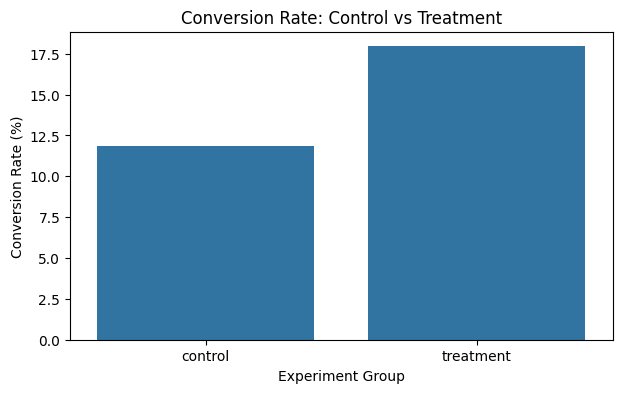

In [9]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=conversion_rate.index,
    y=conversion_rate.values
)

plt.title("Conversion Rate: Control vs Treatment")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [11]:
control_cr = conversion_rate.loc["control"]
treatment_cr = conversion_rate.loc["treatment"]

absolute_lift = treatment_cr - control_cr

relative_lift = (
    (treatment_cr - control_cr)
    / control_cr
) * 100

print(f"Absolute Lift: {absolute_lift:.2f} percentage points")
print(f"Relative Lift: {relative_lift:.2f}%")

Absolute Lift: 6.08 percentage points
Relative Lift: 51.22%


In [12]:
revenue_summary = (
    df.groupby("group")
      .agg(
          Total_Revenue=("purchase_amount", "sum"),
          Average_Revenue_Per_User=("purchase_amount", "mean")
      )
      .round(2)
)

revenue_summary

,Total_Revenue,Average_Revenue_Per_User
group,,
control,654227.55,4.45
treatment,997938.36,6.76


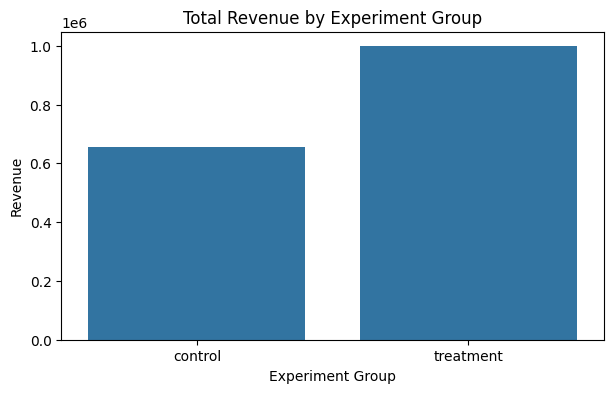

In [13]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=df,
    x="group",
    y="purchase_amount",
    estimator=sum,
    errorbar=None
)

plt.title("Total Revenue by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Revenue")

plt.show()

In [14]:
purchasers = df[df["purchase_amount"] > 0]

aov = (
    purchasers.groupby("group")["purchase_amount"]
    .mean()
    .round(2)
)

aov

group
control      37.50
treatment    37.68
Name: purchase_amount, dtype: float64

In [15]:
session_summary = (
    df.groupby("group")["session_duration"]
      .agg(["mean", "median", "std"])
      .round(2)
)

session_summary

,mean,median,std
group,,,
control,5.0,5.00,1.98
treatment,5.0,4.98,1.98


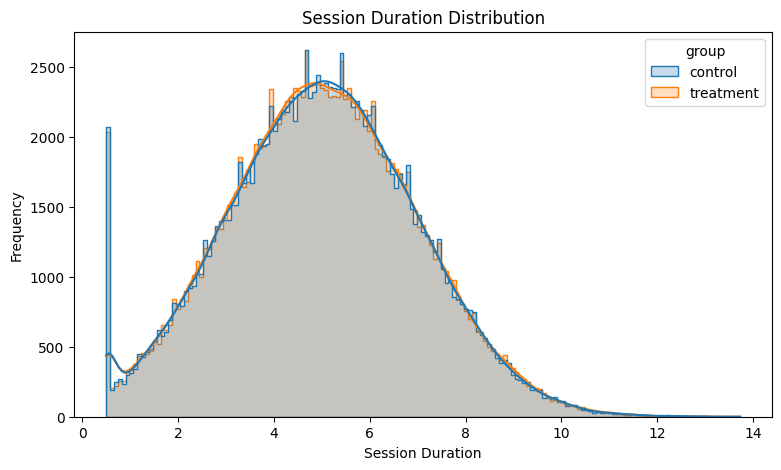

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="session_duration",
    hue="group",
    kde=True,
    element="step"
)

plt.title("Session Duration Distribution")
plt.xlabel("Session Duration")
plt.ylabel("Frequency")

plt.show()

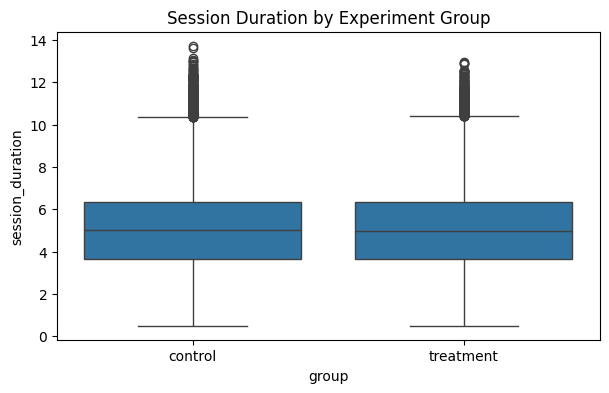

In [17]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="group",
    y="session_duration"
)

plt.title("Session Duration by Experiment Group")

plt.show()

In [18]:
pages_summary = (
    df.groupby("group")["pages_visited"]
      .agg(["mean", "median"])
      .round(2)
)

pages_summary

,mean,median
group,,
control,4.02,4.0
treatment,4.02,4.0


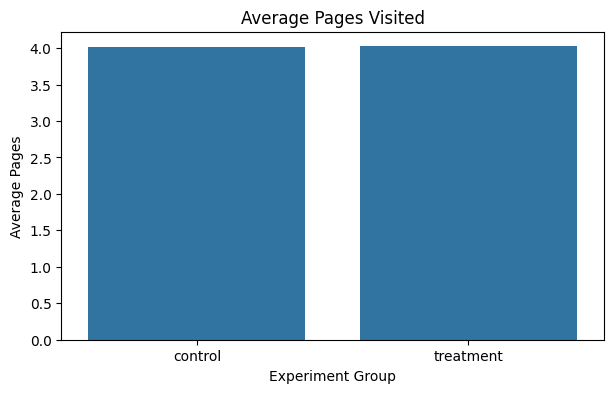

In [19]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=df,
    x="group",
    y="pages_visited",
    errorbar=None
)

plt.title("Average Pages Visited")
plt.xlabel("Experiment Group")
plt.ylabel("Average Pages")

plt.show()

In [21]:
device_distribution = pd.crosstab(
    df["device_type"],
    df["group"]
)

device_distribution

group,control,treatment
device_type,,
Desktop,88397,88295
Mobile,51177,51916
Tablet,7352,7341


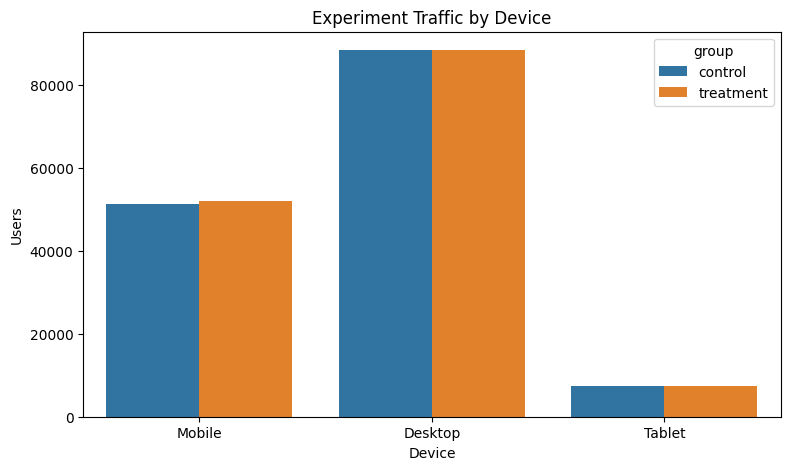

In [23]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="device_type",
    hue="group"
)

plt.title("Experiment Traffic by Device")
plt.xlabel("Device")
plt.ylabel("Users")

plt.show()

In [25]:
device_conversion = (
    df.groupby(["device_type", "group"])["converted"]
      .mean()
      .mul(100)
      .reset_index()
)

device_conversion

,device_type,group,converted
0,Desktop,control,11.949501
1,Desktop,treatment,18.082564
2,Mobile,control,11.743557
3,Mobile,treatment,17.713229
4,Tablet,control,11.847116
5,Tablet,treatment,18.008446


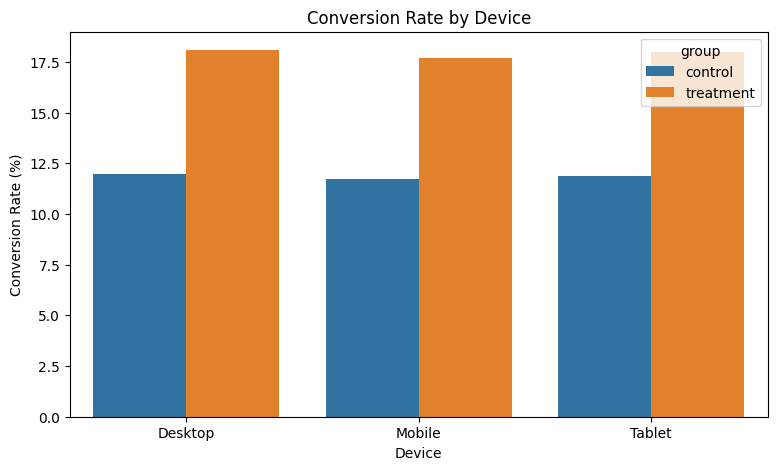

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_conversion,
    x="device_type",
    y="converted",
    hue="group"
)

plt.title("Conversion Rate by Device")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Device")

plt.show()

In [27]:
age_conversion = (
    df.groupby(["age_group", "group"], observed=True)["converted"]
      .mean()
      .mul(100)
      .reset_index()
)

age_conversion

,age_group,group,converted
0,18-24,control,12.013069
1,18-24,treatment,18.093451
2,25-34,control,12.060228
3,25-34,treatment,17.955292
4,35-44,control,11.534422
5,35-44,treatment,17.958340
6,45-59,control,11.802684
7,45-59,treatment,17.510564
8,60+,control,11.286089
9,60+,treatment,18.472906


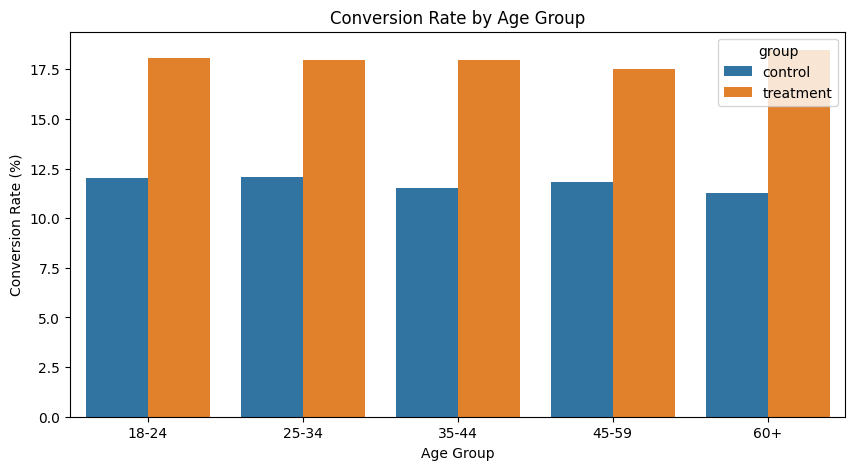

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_conversion,
    x="age_group",
    y="converted",
    hue="group"
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [29]:
hourly_conversion = (
    df.groupby(["hour", "group"])["converted"]
      .mean()
      .mul(100)
      .reset_index()
)

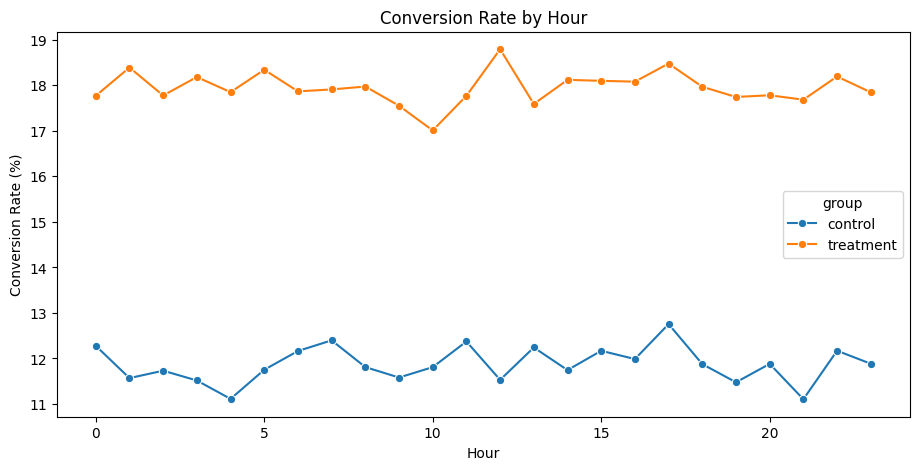

In [30]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hourly_conversion,
    x="hour",
    y="converted",
    hue="group",
    marker="o"
)

plt.title("Conversion Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [31]:
weekend_conversion = (
    df.groupby(["is_weekend", "group"])["converted"]
      .mean()
      .mul(100)
      .reset_index()
)

weekend_conversion

,is_weekend,group,converted
0,False,control,11.854537
1,False,treatment,17.869073
2,True,control,11.918139
3,True,treatment,18.148412


In [32]:
weekend_conversion["day_type"] = (
    weekend_conversion["is_weekend"]
    .map({
        False: "Weekday",
        True: "Weekend"
    })
)

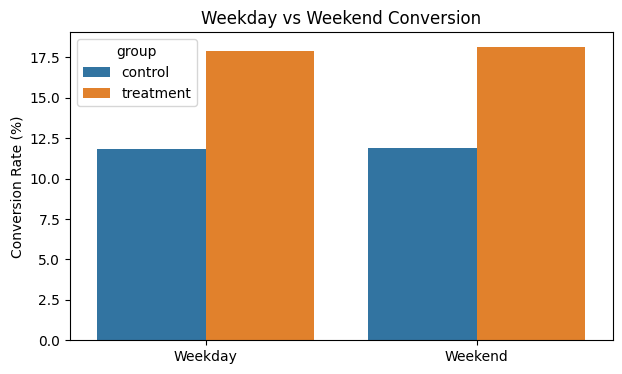

In [33]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=weekend_conversion,
    x="day_type",
    y="converted",
    hue="group"
)

plt.title("Weekday vs Weekend Conversion")
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")

plt.show()

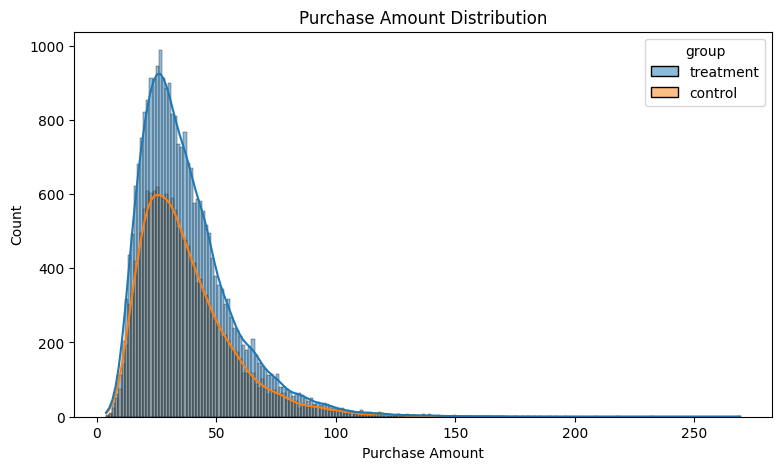

In [34]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df[df["purchase_amount"] > 0],
    x="purchase_amount",
    hue="group",
    kde=True
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")

plt.show()

In [35]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,converted,age,session_duration,pages_visited,purchase_amount,hour
converted,1.000000,-0.004452,-0.000328,0.001650,0.867934,0.000318
age,-0.004452,1.000000,0.001571,0.001453,-0.002424,0.002585
session_duration,-0.000328,0.001571,1.000000,0.000909,-0.000595,-0.000250
pages_visited,0.001650,0.001453,0.000909,1.000000,0.001709,0.001531
purchase_amount,0.867934,-0.002424,-0.000595,0.001709,1.000000,0.000936
hour,0.000318,0.002585,-0.000250,0.001531,0.000936,1.000000


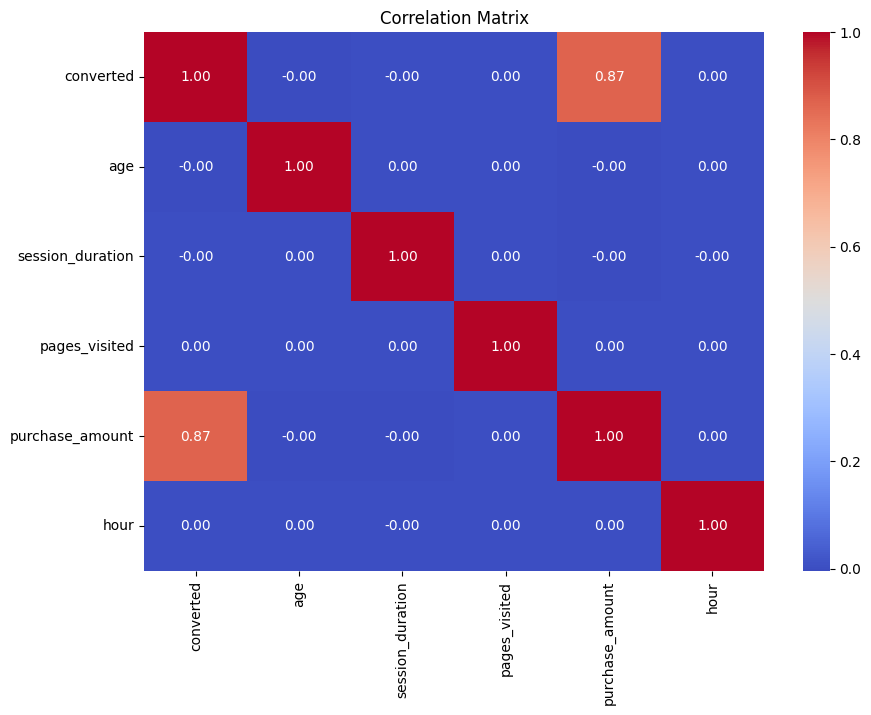

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [37]:
kpi_summary = df.groupby("group").agg(

    Users=("user_id", "nunique"),

    Conversion_Rate=("converted", "mean"),

    Revenue=("purchase_amount", "sum"),

    Revenue_Per_User=("purchase_amount", "mean"),

    Avg_Session_Duration=("session_duration", "mean"),

    Avg_Pages_Visited=("pages_visited", "mean")

)

kpi_summary["Conversion_Rate"] *= 100

kpi_summary.round(2)

,Users,Conversion_Rate,Revenue,Revenue_Per_User,Avg_Session_Duration,Avg_Pages_Visited
group,,,,,,
control,146926,11.87,654227.55,4.45,5.0,4.02
treatment,147552,17.95,997938.36,6.76,5.0,4.02


In [38]:
kpi_summary["Average_Order_Value"] = (
    purchasers
    .groupby("group")["purchase_amount"]
    .mean()
)

kpi_summary.round(2)

,Users,Conversion_Rate,Revenue,Revenue_Per_User,Avg_Session_Duration,Avg_Pages_Visited,Average_Order_Value
group,,,,,,,
control,146926,11.87,654227.55,4.45,5.0,4.02,37.50
treatment,147552,17.95,997938.36,6.76,5.0,4.02,37.68


In [39]:
kpi_summary.to_csv(
    "../Output/experiment_summary.csv"
)